### Minicurso Sistemas Multi-agente com LangGraph

## Sistema Multi Agente 

Moacir Antonelli Ponti - 2025

---

In [1]:
from typing import TypedDict, Optional, Dict, Any
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, END
from dotenv import load_dotenv

load_dotenv()

True

Vamos propor um sistema multi-agente que tenha 2 LLMs:
1) É um gerador de questões de múltipla-escolha
2) É um avaliador de questões

In [2]:
class ExamState(TypedDict):
    topic: str
    difficulty: str
    draft_question: str
    review_feedback: str
    approved: bool 

In [4]:
llm_generator = ChatOpenAI(model="gpt-4o-mini")
llm_reviewer  = ChatOpenAI(model="gpt-5-mini")

In [5]:
def generate_question(state: ExamState) -> ExamState:
    refinement_prompt = f"""
    Você um professor capaz de gerar questões de múltipla escolha para exames.
    Gere uma questão original considerando os seguintes parâmetros:
    Nível de dificuldade {state['difficulty']}
    Formato obrigatório:
    Enunciado
    A) ...
    B) ...
    C) ...
    D) ...
    Gabarito: X
    """
    ###
    if state.get("review_feedback"):
        refinement_prompt += f"""Considere o feedback crítico de um avaliador:
        {state['review_feedback']}, reescreva a questão mantendo o tema e o nível,
        porém considerando o feedback.
        """

    resp = llm_generator.invoke(refinement_prompt)
    state['draft_question'] = resp.content
    print(f"Questão gerada:\n{state['draft_question']}\n")
    return state

In [6]:
def review_question(state: ExamState) -> ExamState:
    prompt = f"""
    Você um professor extremamente rigoroso na avaliação de questões de múltipla escolha para exames.

    Considere a seguinte questão proposta:
    {state['draft_question']}

    Avalie os seguintes pontos:
    - clareza do enunciado no tópico ({state['topic']})
    - ausência de ambiguidade
    - alternativas plausíveis
    - gabarito coerente
    - nível adequado (deveria ser {state['difficulty']})

    Responda no seguinte formato ReAct:

    Caso esteja fora do tópico, retorne imediatamente "request_changes".

    Thought: analise profundamente
    Action:
      - "approve" se a questão está perfeita
      - "request_changes" se ela contém erros
    Feedback: explique detalhadamente por quê
    """
    
    resp = llm_reviewer.invoke(prompt).content

    action = "approve" if "approve" in resp.lower() else "request_changes"

    state["approved"] = action == "approve"
    state["review_feedback"] = resp

    print(f"Questao avaliada:\n- Aprovada {state['approved']}\n- Feedback: {state['review_feedback']}")

    return state


In [7]:
graph = StateGraph(ExamState)

graph.add_node("generator", generate_question)
graph.add_node("reviewer", review_question)

graph.set_entry_point("generator")

# Fluxo padrão
graph.add_edge("generator", "reviewer")

# Loop ReAct: se reprovado, volta para o gerador
def should_retry(state: ExamState) -> bool:
    return not state["approved"]

graph.add_conditional_edges(
    "reviewer",
    should_retry,
    {
        True: "generator",  # volta para refazer
        False: END          # termina
    }
)

app = graph.compile()


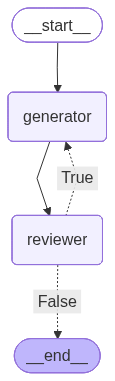

In [8]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [9]:
initial_state = {
    "topic": "Física / Leis de Newton",
    "difficulty": "médio",
    "draft_question": None,
    "review_feedback": None,
    "approved": False
}

result = app.invoke(initial_state)

Questão gerada:
Enunciado: Qual dos seguintes planetas do sistema solar é conhecido por ter um grande anel visível?

A) Marte  
B) Vênus  
C) Júpiter  
D) Saturno  

Gabarito: D

Questao avaliada:
- Aprovada False
- Feedback: request_changes
Questão gerada:
**Enunciado:** Qual dos seguintes elementos é considerado um dos principais responsáveis pela formação das correntes oceânicas?

A) Temperatura da água  
B) Salinidade da água  
C) Vento  
D) Fretamento terrestre  

Gabarito: C

---

**Feedback do avaliador:** A questão está boa, mas poderia incluir um contexto maior ou uma aplicação prática para que os alunos possam refletir melhor sobre as razões por trás da resposta correta.

**Reescrita da questão:**

**Enunciado:** Em um estudo sobre as correntes oceânicas, um grupo de alunos chega à conclusão de que vários fatores influenciam a movimentação das águas. Qual deles é considerado um dos principais responsáveis pela formação das correntes oceânicas, ajudando a determinar sua direçã

In [10]:

print("Questão final aprovada:\n", result["draft_question"])
print("\nFeedback final do avaliador:\n", result["review_feedback"])

Questão final aprovada:
 **Enunciado:** De acordo com as leis de Newton, qual dos seguintes fatores exerce diretamente uma força sobre a superfície do oceano, transferindo momento e iniciando o movimento das correntes superficiais?

A) Gradientes de temperatura que alteram a densidade da água  
B) Variações de salinidade que alteram a densidade da água  
C) Força aplicada pelo vento sobre a superfície  
D) Atrito com o fundo do oceano  

**Gabarito:** C

**Observação:** Justifique sua resposta explicando como a força e a transferência de momento do vento influenciam o movimento das correntes superficiais em comparação com os outros fatores.

Feedback final do avaliador:
 Thought: analise profundamente

Action:
- "approve"

Feedback:
A questão está, em grande parte, bem formulada e adequada ao tópico (Física / Leis de Newton). Comentários detalhados:

1) Clareza do enunciado:
- O enunciado é claro ao pedir qual fator "exerce diretamente uma força sobre a superfície do oceano, transferin